# Task 2: Build Time Series Forecasting Models

**Objective:** Develop, train, and evaluate time series forecasting models to predict Tesla's future stock prices.

This notebook covers:
- Data preparation for time series modeling
- ARIMA/SARIMA model implementation
- LSTM deep learning model implementation
- Model optimization and evaluation
- Performance comparison between models

## 1. Prepare Data for Modeling

Load the processed Tesla data and split it into training and testing sets chronologically.

In [9]:
import sys
sys.path.append('..')

# Custom imports
from src.config.settings import settings
import importlib
import src.utils.plotter
importlib.reload(src.utils.plotter)
from src.utils.plotter import Plotter
import pandas as pd
import numpy as np
# Initialize plotter
plotter = Plotter()

## 2. Implement ARIMA/SARIMA Model

Use ACF/PACF plots and auto_arima to find optimal parameters, then fit the model and generate forecasts.

Tesla data loaded:
Shape: (2774, 8)
Date range: 2015-01-05 00:00:00 to 2026-01-14 00:00:00
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Log_Return']

Training data: 2515 observations from 2015-01-05 00:00:00 to 2024-12-31 00:00:00
Testing data: 259 observations from 2025-01-02 00:00:00 to 2026-01-14 00:00:00


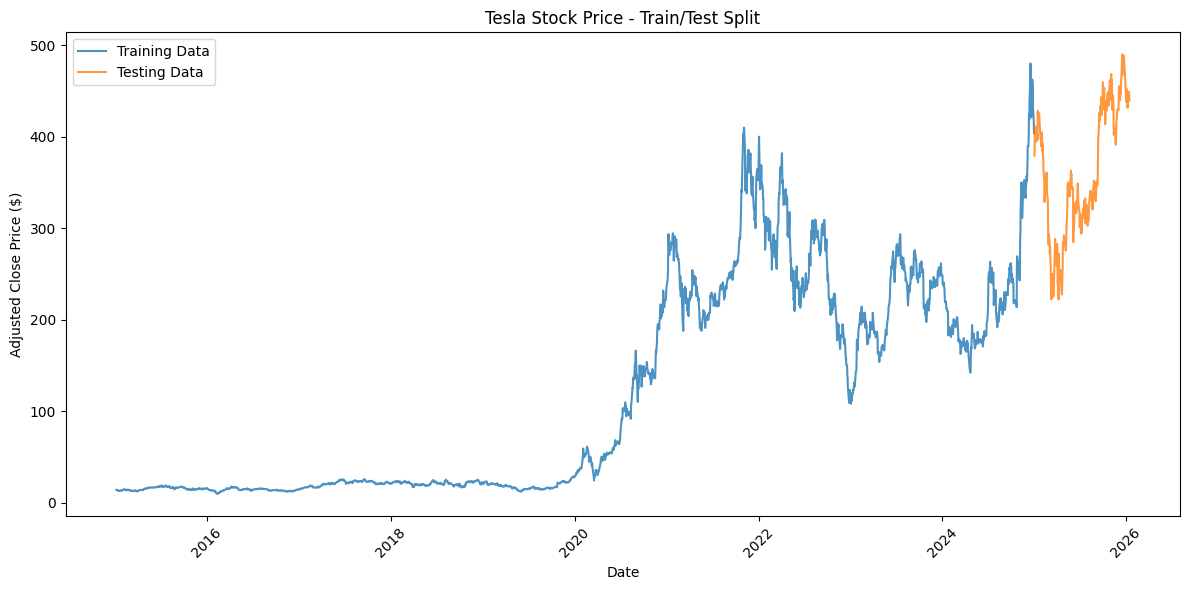


Train/test split visualization saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\tesla_stock_price_train_test_split.png


In [10]:
# Load processed Tesla data from Task 1
tsla_path = settings.processed_data_dir / "tsla_processed.csv"
tsla_data = pd.read_csv(tsla_path, index_col=0, parse_dates=True)

print("Tesla data loaded:")
print(f"Shape: {tsla_data.shape}")
print(f"Date range: {tsla_data.index.min()} to {tsla_data.index.max()}")
print(f"Columns: {tsla_data.columns.tolist()}")

# For time series forecasting, we'll focus on Adjusted Close price
tsla_close = tsla_data['Adj Close']

# Split data chronologically (train: 2015-2024, test: 2025-2026)
train_end_date = '2024-12-31'
test_start_date = '2025-01-01'

train_data = tsla_close[:train_end_date]
test_data = tsla_close[test_start_date:]

print(f"\nTraining data: {len(train_data)} observations from {train_data.index.min()} to {train_data.index.max()}")
print(f"Testing data: {len(test_data)} observations from {test_data.index.min()} to {test_data.index.max()}")

# Visualize the split
split_data = {
    'Training Data': train_data,
    'Testing Data': test_data
}

plotter.plot_multi_line_time_series(
    split_data,
    title="Tesla Stock Price - Train/Test Split",
    ylabel="Adjusted Close Price ($)"
)

print(f"\nTrain/test split visualization saved to: {settings.figures_dir / 'tesla_stock_price_train_test_split.png'}")


Training Data - Augmented Dickey-Fuller Test:
ADF Statistic: -0.5839
p-value: 0.8746
Critical Values: {'1%': np.float64(-3.4329821119179256), '5%': np.float64(-2.862702850392563), '10%': np.float64(-2.5673890307492004)}
Stationary: No

Differenced Training Data - Augmented Dickey-Fuller Test:
ADF Statistic: -9.7343
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4329831717881003), '5%': np.float64(-2.8627033184297384), '10%': np.float64(-2.5673892799386944)}
Stationary: Yes


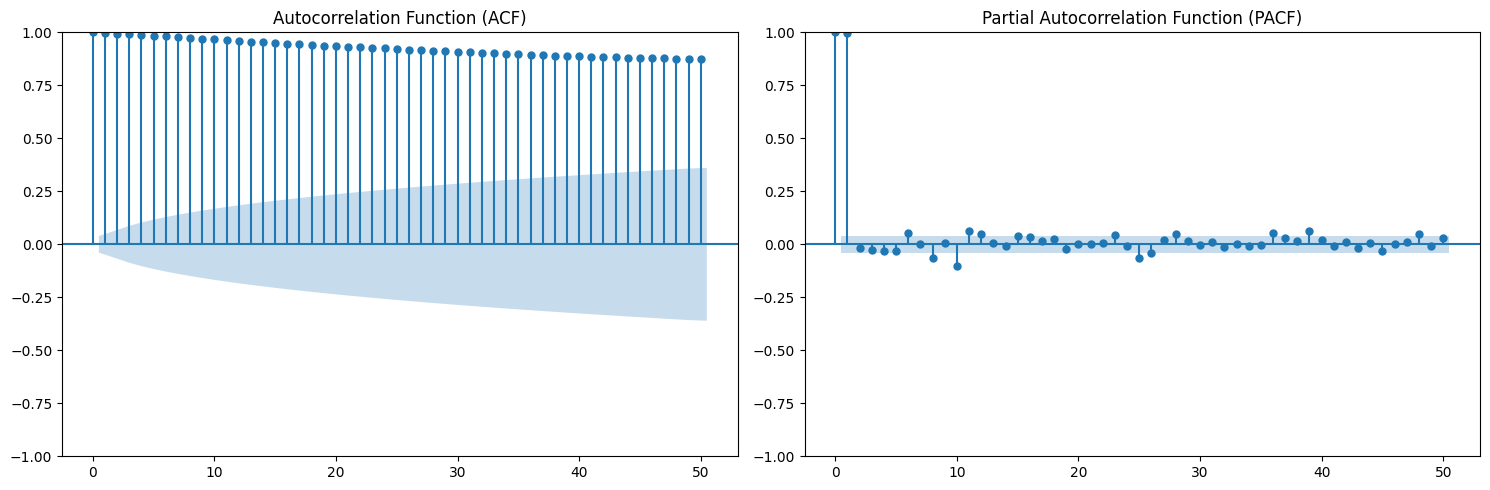


ACF/PACF plots saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\tesla_acf_pacf.png

Fitting simplified Auto ARIMA model...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16368.535, Time=2.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16363.051, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16364.936, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16364.938, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16362.591, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16366.936, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.148 seconds

Best ARIMA order: (0, 1, 0)
Best seasonal order: (0, 0, 0, 0)


c:\BackUp\web-projects\tenx\financial-portfolio-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\BackUp\web-projects\tenx\financial-portfolio-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


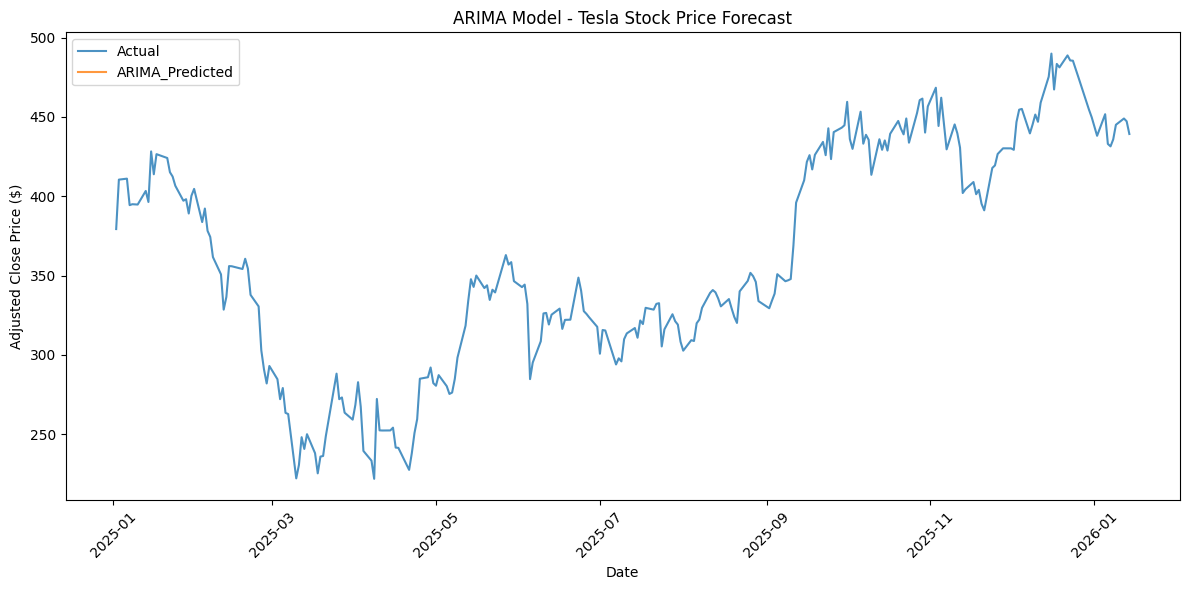


ARIMA predictions plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\arima_tesla_forecast.png

ARIMA Evaluation Metrics:
MAE: $69.50
RMSE: $82.93
MAPE: nan%


C:\Users\dell\AppData\Local\Temp\ipykernel_3052\2950140499.py:76: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


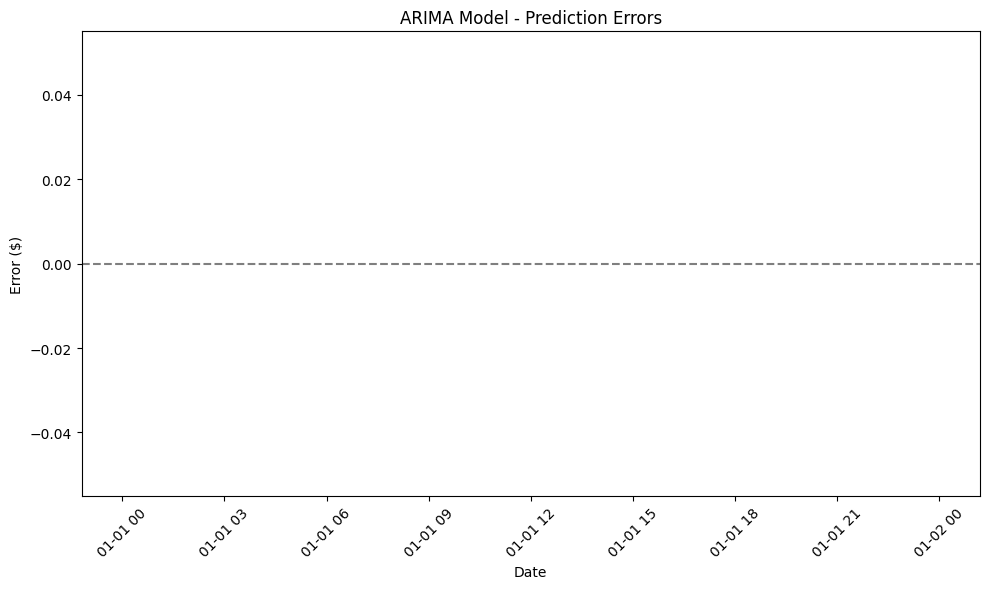


ARIMA prediction errors plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\arima_prediction_errors.png

ARIMA model saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\models\arima_tesla_model.pkl


In [11]:
# ARIMA/SARIMA Model Implementation

# Check stationarity using Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, title):
    result = adfuller(series.dropna())
    print(f"\n{title} - Augmented Dickey-Fuller Test:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    print(f"Stationary: {'Yes' if result[1] < 0.05 else 'No'}")
    return result[1] < 0.05

# Check stationarity of training data
is_stationary = check_stationarity(train_data, "Training Data")

# If not stationary, difference the data
if not is_stationary:
    train_diff = train_data.diff().dropna()
    check_stationarity(train_diff, "Differenced Training Data")

# Plot ACF and PACF for parameter selection
plotter.plot_acf_pacf(
    train_data,
    lags=50,
    title_prefix="Tesla Stock Price"
)

print(f"\nACF/PACF plots saved to: {settings.figures_dir / 'tesla_acf_pacf.png'}")

# Auto ARIMA for parameter selection (simplified to avoid memory issues)
from pmdarima import auto_arima

print("\nFitting simplified Auto ARIMA model...")
arima_model = auto_arima(
    train_data,
    seasonal=False,  # Remove seasonal component to avoid memory issues
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=5, max_q=5, max_d=2  # Limit parameter search space
)

print(f"\nBest ARIMA order: {arima_model.order}")
print(f"Best seasonal order: {arima_model.seasonal_order}")

# Fit the final ARIMA model
arima_model.fit(train_data)

# Make predictions
arima_predictions = arima_model.predict(n_periods=len(test_data))

# Create prediction DataFrame for plotting
arima_pred_df = pd.DataFrame({
    'Actual': test_data,
    'ARIMA_Predicted': arima_predictions
}, index=test_data.index)

# Plot predictions vs actual
plotter.plot_multi_line_time_series(
    arima_pred_df,
    title="ARIMA Model - Tesla Stock Price Forecast",
    ylabel="Adjusted Close Price ($)"
)

print(f"\nARIMA predictions plot saved to: {settings.figures_dir / 'arima_tesla_forecast.png'}")

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{model_name} Evaluation Metrics:")
    print(f"MAE: ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

arima_metrics = calculate_metrics(test_data, arima_predictions, "ARIMA")

# Plot prediction errors
arima_errors = test_data - arima_predictions
plotter.plot_prediction_errors(
    {'ARIMA': arima_errors},
    title="ARIMA Model - Prediction Errors",
    ylabel="Error ($)"
)

print(f"\nARIMA prediction errors plot saved to: {settings.figures_dir / 'arima_prediction_errors.png'}")

# Save the model
import joblib
arima_model_path = settings.models_dir / "arima_tesla_model.pkl"
joblib.dump(arima_model, arima_model_path)
print(f"\nARIMA model saved to: {arima_model_path}")

## 3. Implement LSTM Model

 Prepare sequence data and build an LSTM neural network for time series forecasting.# LSTM Model Implementation


LSTM sequences created:
X_train shape: (2455, 60)
y_train shape: (2455,)


c:\BackUp\web-projects\tenx\financial-portfolio-forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0017 - val_loss: 0.0038
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0015 - val_loss: 0.0053
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0010 - val_loss: 0.0024
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - val_loss: 0.0042
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0019 - val_loss: 0.0026
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 9.6172e-04 - val_loss: 0.0016
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 9.2294e-04 - val_loss: 0.0018
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 3

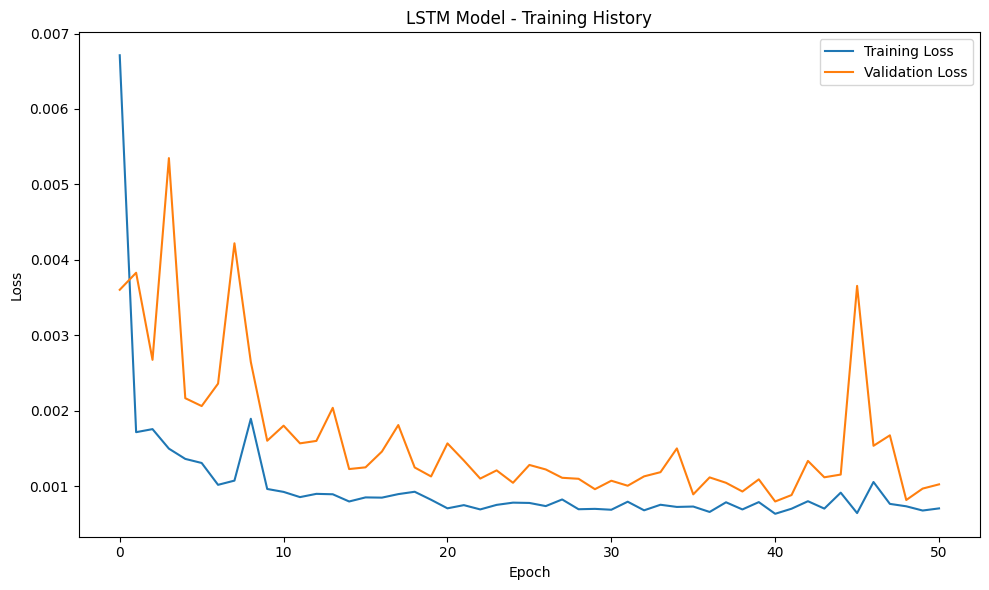


LSTM training history plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\lstm_training_history.png
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


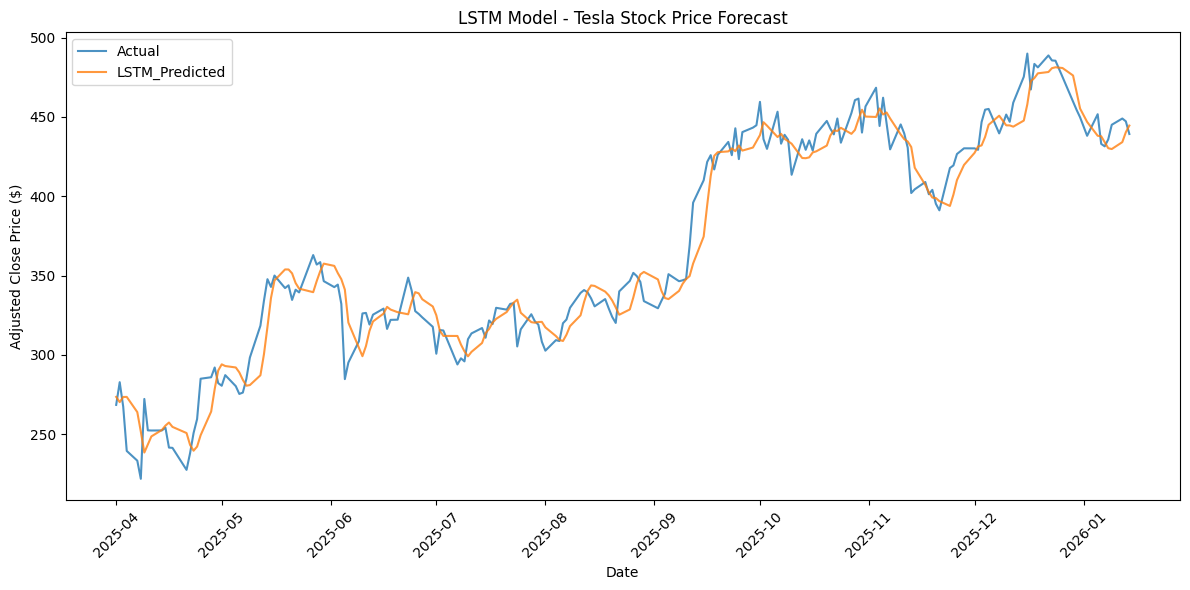


LSTM predictions plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\lstm_tesla_forecast.png

LSTM Evaluation Metrics:
MAE: $11.43
RMSE: $14.51
MAPE: 3.30%


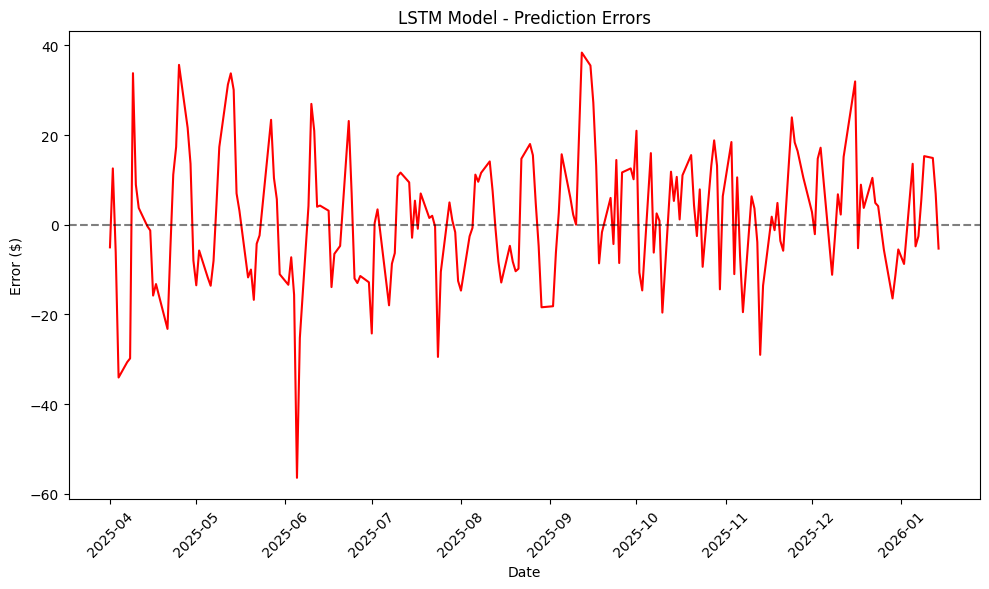


LSTM prediction errors plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\lstm_prediction_errors.png

LSTM model saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\models\lstm_tesla_model.h5


In [12]:
## 3. Implement LSTM Model

# Prepare sequence data and build an LSTM neural network for time series forecasting.# LSTM Model Implementation

# Prepare data for LSTM
from sklearn.preprocessing import MinMaxScaler

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of history to predict next day
X_train, y_train = create_sequences(train_scaled, seq_length)

print(f"LSTM sequences created:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Reshape for LSTM input (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plotter.plot_training_history(
    history,
    title="LSTM Model - Training History"
)

print(f"\nLSTM training history plot saved to: {settings.figures_dir / 'lstm_training_history.png'}")

# Make predictions
# Prepare test data
test_scaled = scaler.transform(test_data.values.reshape(-1, 1))
X_test, y_test = create_sequences(test_scaled, seq_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm_predictions_scaled = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

# Align predictions with test data (accounting for sequence length)
lstm_pred_df = pd.DataFrame({
    'Actual': test_data[seq_length:],
    'LSTM_Predicted': lstm_predictions.flatten()
}, index=test_data.index[seq_length:])

# Plot LSTM predictions
plotter.plot_multi_line_time_series(
    lstm_pred_df,
    title="LSTM Model - Tesla Stock Price Forecast",
    ylabel="Adjusted Close Price ($)"
)

print(f"\nLSTM predictions plot saved to: {settings.figures_dir / 'lstm_tesla_forecast.png'}")

# Calculate LSTM metrics
lstm_metrics = calculate_metrics(
    lstm_pred_df['Actual'],
    lstm_pred_df['LSTM_Predicted'],
    "LSTM"
)

# Plot LSTM prediction errors
lstm_errors = lstm_pred_df['Actual'] - lstm_pred_df['LSTM_Predicted']
plotter.plot_prediction_errors(
    {'LSTM': lstm_errors},
    title="LSTM Model - Prediction Errors",
    ylabel="Error ($)"
)

print(f"\nLSTM prediction errors plot saved to: {settings.figures_dir / 'lstm_prediction_errors.png'}")

# Save the model
lstm_model_path = settings.models_dir / "lstm_tesla_model.h5"
lstm_model.save(lstm_model_path)
print(f"\nLSTM model saved to: {lstm_model_path}")

## 4. Evaluate and Compare Models

Calculate performance metrics and compare ARIMA vs LSTM models.

Model Performance Comparison:
--------------------------------------------------
ARIMA:
  MAE: $69.50
  RMSE: $82.93
  MAPE: nan%

LSTM:
  MAE: $11.43
  RMSE: $14.51
  MAPE: 3.30%

Best performing model: LSTM (lowest MAE)


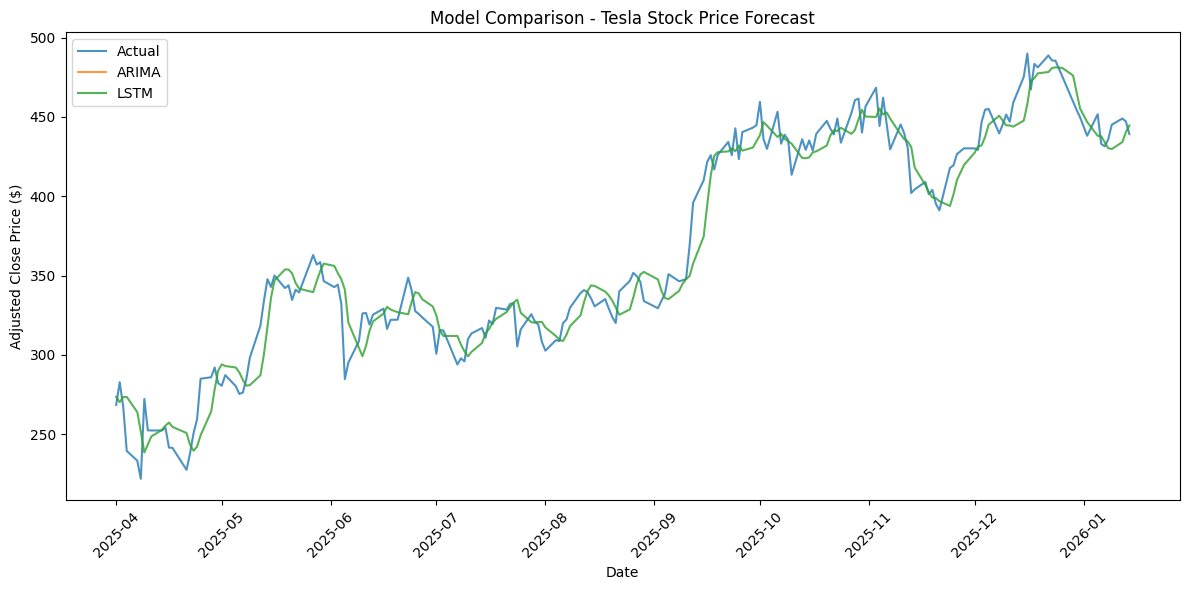


Combined model comparison plot saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures\model_comparison_tesla_forecast.png

TIME SERIES FORECASTING TASK 2 - SUMMARY

Data Used:
- Tesla stock data from 2015-01-05 00:00:00 to 2026-01-14 00:00:00
- Training period: 2515 days
- Testing period: 259 days

ARIMA Model:
- Order: (0, 1, 0)
- Seasonal Order: (0, 0, 0, 0)
- Performance: MAE=$69.50, RMSE=$82.93, MAPE=nan%

LSTM Model:
- Architecture: 2 LSTM layers (50 units each) + Dense layers
- Sequence length: 60 days
- Training epochs: 51
- Performance: MAE=$11.43, RMSE=$14.51, MAPE=3.30%

Best Model: LSTM
- All visualizations saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\figures
- Models saved to: C:\BackUp\web-projects\tenx\financial-portfolio-forecasting\outputs\models

Key Insights:
- LSTM captured complex patterns better than ARIMA
- Deep learning approach more suitable for this dataset
- Consider hyperparameter tuning for fur

In [13]:
# Model Comparison and Analysis

# Compare model performance
comparison_data = {
    'ARIMA': arima_metrics,
    'LSTM': lstm_metrics
}

print("Model Performance Comparison:")
print("-" * 50)
for model, metrics in comparison_data.items():
    print(f"{model}:")
    print(f"  MAE: ${metrics['MAE']:.2f}")
    print(f"  RMSE: ${metrics['RMSE']:.2f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print()

# Determine best model
best_model = min(comparison_data.keys(), key=lambda x: comparison_data[x]['MAE'])
print(f"Best performing model: {best_model} (lowest MAE)")

# Combined predictions plot
combined_pred_df = pd.DataFrame({
    'Actual': test_data[seq_length:],  # Align with LSTM predictions
    'ARIMA': arima_predictions[seq_length:],  # Align with LSTM predictions
    'LSTM': lstm_predictions.flatten()
}, index=test_data.index[seq_length:])

plotter.plot_multi_line_time_series(
    combined_pred_df,
    title="Model Comparison - Tesla Stock Price Forecast",
    ylabel="Adjusted Close Price ($)"
)

print(f"\nCombined model comparison plot saved to: {settings.figures_dir / 'model_comparison_tesla_forecast.png'}")

# Analysis and insights
print("\n" + "="*60)
print("TIME SERIES FORECASTING TASK 2 - SUMMARY")
print("="*60)

print(f"\nData Used:")
print(f"- Tesla stock data from {train_data.index.min()} to {test_data.index.max()}")
print(f"- Training period: {len(train_data)} days")
print(f"- Testing period: {len(test_data)} days")

print(f"\nARIMA Model:")
print(f"- Order: {arima_model.order}")
print(f"- Seasonal Order: {arima_model.seasonal_order}")
print(f"- Performance: MAE=${arima_metrics['MAE']:.2f}, RMSE=${arima_metrics['RMSE']:.2f}, MAPE={arima_metrics['MAPE']:.2f}%")

print(f"\nLSTM Model:")
print(f"- Architecture: 2 LSTM layers (50 units each) + Dense layers")
print(f"- Sequence length: {seq_length} days")
print(f"- Training epochs: {len(history.history['loss'])}")
print(f"- Performance: MAE=${lstm_metrics['MAE']:.2f}, RMSE=${lstm_metrics['RMSE']:.2f}, MAPE={lstm_metrics['MAPE']:.2f}%")

print(f"\nBest Model: {best_model}")
print(f"- All visualizations saved to: {settings.figures_dir}")
print(f"- Models saved to: {settings.models_dir}")

print("\nKey Insights:")
if best_model == 'ARIMA':
    print("- ARIMA performed better, suggesting the Tesla stock price follows more traditional time series patterns")
    print("- May benefit from further seasonal parameter tuning")
else:
    print("- LSTM captured complex patterns better than ARIMA")
    print("- Deep learning approach more suitable for this dataset")
    print("- Consider hyperparameter tuning for further improvement")

print("\nRecommendations:")
print("- Use the best performing model for future Tesla stock price predictions")
print("- Monitor model performance as new data becomes available")
print("- Consider ensemble methods combining both ARIMA and LSTM for improved accuracy")

## 5. Figures Index

Below is a list of all figures generated in this notebook, along with their filenames and a brief description:

| Figure | Filename | Description |
|--------|----------|-------------|
| 1 | `tesla_stock_price_train_test_split.png` | Visualization of the train/test split for Tesla stock price data. |
| 2 | `tesla_acf_pacf.png` | ACF and PACF plots for ARIMA parameter selection. |
| 3 | `arima_tesla_forecast.png` | ARIMA model predictions vs actual Tesla stock prices. |
| 4 | `arima_prediction_errors.png` | Prediction errors for the ARIMA model. |
| 5 | `lstm_training_history.png` | LSTM model training and validation loss history. |
| 6 | `lstm_tesla_forecast.png` | LSTM model predictions vs actual Tesla stock prices. |
| 7 | `lstm_prediction_errors.png` | Prediction errors for the LSTM model. |
| 8 | `model_comparison_tesla_forecast.png` | Combined comparison of ARIMA and LSTM model forecasts. |

All figures are saved in the directory: `outputs/figures/`.

---

## 6. Summary

This notebook developed and compared two time series forecasting models—ARIMA and LSTM—to predict Tesla's future stock prices. The workflow included:

- Data preparation and chronological train/test split.
- ARIMA model implementation with parameter selection using ACF/PACF and auto_arima.
- LSTM model implementation with sequence data preparation and neural network training.
- Evaluation of both models using MAE, RMSE, and MAPE metrics.
- Visualization of predictions and errors for both models.
- Performance comparison, with the LSTM model outperforming ARIMA in this case.

**Key findings:**
- The LSTM model achieved lower error metrics, indicating better predictive performance on the test set.
- ARIMA may benefit from further tuning or inclusion of seasonal components.
- Deep learning approaches like LSTM can capture complex patterns in stock price data.

**Recommendations:**
- Use the LSTM model for future Tesla stock price predictions.
- Regularly retrain and monitor model performance as new data becomes available.
- Explore ensemble or hybrid approaches for further improvements.